# Heatmap Correlation 

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [27]:
données = {"Débit (l/s)": [20, 4, 15, 75, 1500, 17, 1483, 1800, 10, 1000, 5, 25, 3, 1200],
        "Température (C)": [13.3, 12.3, 17.6, 11.4, 12.2, 12.2, 12.4, 11.9, 11.2, 11.2, 10.3, 9.3, 10.3, 12],
        "Conductivité (µS/cm)": [630, 686, 585, 589, 365, 579, 345, 412, 544, 173.5, 218, 138.8, 219, 257],
        "pH": [8.01, 7.87, 8.17, 8.1, 8.355, 8.354, 8.35, 8.342, 8.1, 8.3, 8.24, 7.3, 7.63, 8.79]}
    
df = pd.DataFrame(données)
correlation = df.corr()

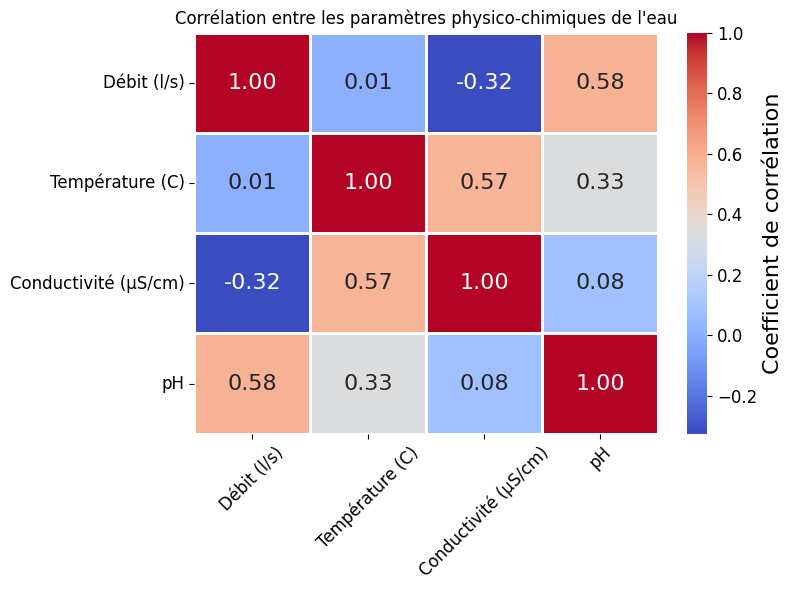

In [28]:
#  Correlation Heatmap

plt.figure(figsize=(8, 6))
ax = sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.8, cbar_kws={"label": "Coefficient de corrélation"}, annot_kws={"size": 16})
    
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)  
cbar.set_label("Coefficient de corrélation", fontsize=16)  

plt.title("Corrélation entre les paramètres physico-chimiques de l'eau", fontsize=12)
plt.tight_layout()
plt.show()


# Significance test for Correlation coefficient

Les deux Hypothèses (nulle et alternative) sont comme les suivants:

H0 = Il n’existe aucune corrélation linéaire entre les deux variables. 
   p >= 0.05
H1 = Il existe une corrélation linéaire significative entre les deux variables.
   p < 0.05

In [29]:
from scipy.stats import pearsonr

variables = ["Température (C)", "Conductivité (µS/cm)", "pH"]

for i in variables:
    x = df["Débit (l/s)"]
    y = df[i]
    r, p = pearsonr(x, y)
    print(f"Corrélation entre Débit et {i} : r = {r:.3f}, p-value = {p:.4f}")
    
    if p < 0.05:
        print("      Corrélation statistiquement significative, car (p < 0.05)\n")
    else:
        print("      Corrélation non significative, car (p >= 0.05)\n")


Corrélation entre Débit et Température (C) : r = 0.006, p-value = 0.9849
      Corrélation non significative, car (p >= 0.05)

Corrélation entre Débit et Conductivité (µS/cm) : r = -0.324, p-value = 0.2580
      Corrélation non significative, car (p >= 0.05)

Corrélation entre Débit et pH : r = 0.585, p-value = 0.0280
      Corrélation statistiquement significative, car (p < 0.05)



# Graphical methode of Correlation Analyse

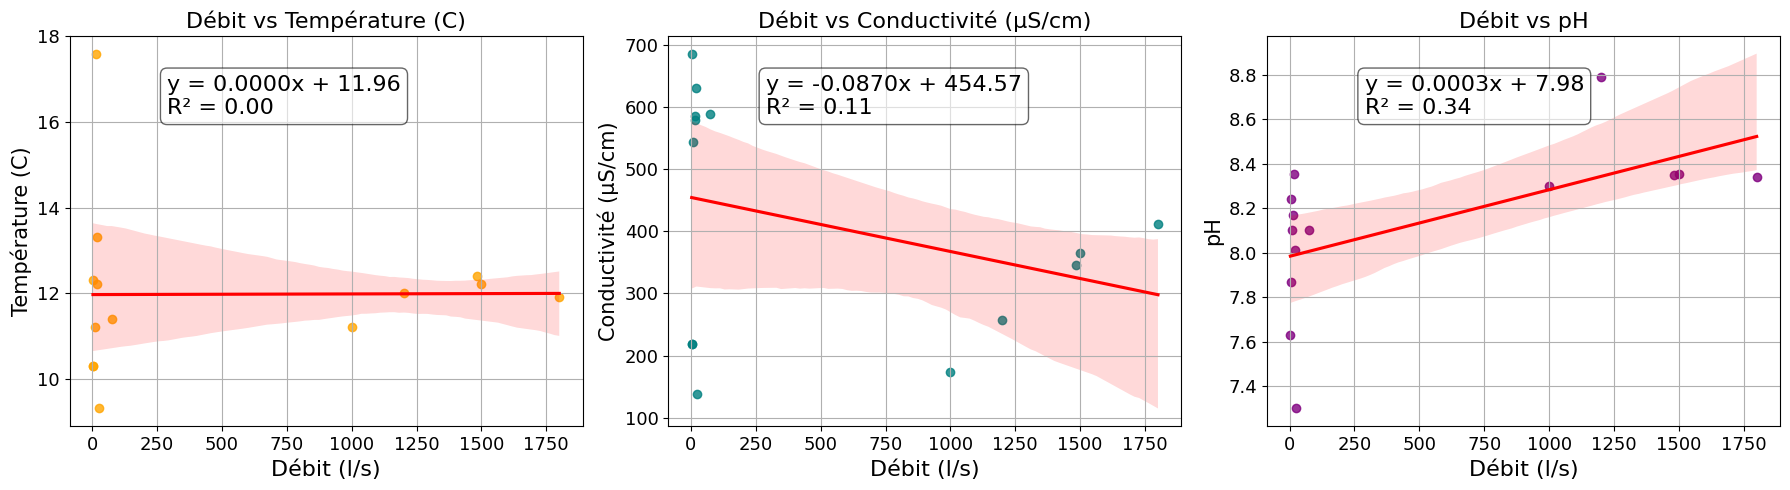

In [30]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
variables = ["Température (C)", "Conductivité (µS/cm)", "pH"]
colors = ["orange", "teal", "purple"]


for i, var in enumerate(variables):
    x = df["Débit (l/s)"]
    y = df[var]
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    equation = f"y = {slope:.4f}x + {intercept:.2f}\nR² = {r_value**2:.2f}"
    
    sns.regplot(x=x, y=y, ax=axs[i], color=colors[i], line_kws={"color": "red"})
    axs[i].set_title(f"Débit vs {var}", fontsize=16)
    
    axs[i].text(0.19, 0.8, equation, transform=axs[i].transAxes,
                fontsize=16, bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))
    
    axs[i].grid(True)
    axs[i].set_xlabel("Débit (l/s)", fontsize=16)
    axs[i].set_ylabel(var, fontsize=15)

   
    axs[i].tick_params(axis='both', labelsize=13)


# plt.suptitle("Analyse graphique avec équation de regression", fontsize=14)
plt.tight_layout()
plt.show()


In [31]:
dataframe = pd.read_excel(r"E:\Universite Grenoble Alpes\S8\Atelier de terrain Hydrometry-Hydrologie (Ardeche)\pysico-chimie de l'eau des rivieres\aire_drainee.xlsx")

dataframe

,point,Aire_draine_amont(m2),Aire_draine_amont(km2),S_basalt_m2,Surface_formation_basaltiques(km2),pourcentage de basalt dans le BV,S_sedim_m2,Surface_formation_sedimentaire(km2),pourcentage de formations sedimentaire dans le BV,Unnamed: 9,conductivite,pH
0,1,1701609,1.701609,1.695973e+06,1.695973,99.668784,0,0.000000,0.000000,NaN,138.8,7.300
1,3,12249545,12.249545,1.127310e+07,11.273095,92.028684,634050,0.634050,5.176111,NaN,173.5,8.300
2,4,259722,0.259722,3.083000e+03,0.003083,1.187038,0,0.000000,0.000000,NaN,219.0,7.630
3,5,22562682,22.562682,1.616559e+07,16.165591,71.647471,4613500,4.613500,20.447480,NaN,257.0,8.790
4,6,500523,0.500523,0.000000e+00,0.000000,0.000000,488817,0.488817,97.661246,NaN,544.0,8.100
5,7,1080153,1.080153,0.000000e+00,0.000000,0.000000,1073822,1.073822,99.413879,NaN,585.0,8.170
6,10,3816646,3.816646,8.606400e+04,0.086064,2.254964,3077497,3.077497,80.633546,NaN,579.0,8.354
7,11,30169861,30.169861,1.641255e+07,16.412554,54.400496,10981078,10.981078,36.397509,NaN,345.0,8.350
8,12,34153744,34.153744,1.651845e+07,16.518452,48.364982,14147677,14.147677,41.423503,NaN,589.0,8.100
9,13,42390601,42.390601,1.690173e+07,16.901728,39.871405,21535126,21.535126,50.801653,NaN,365.0,8.355


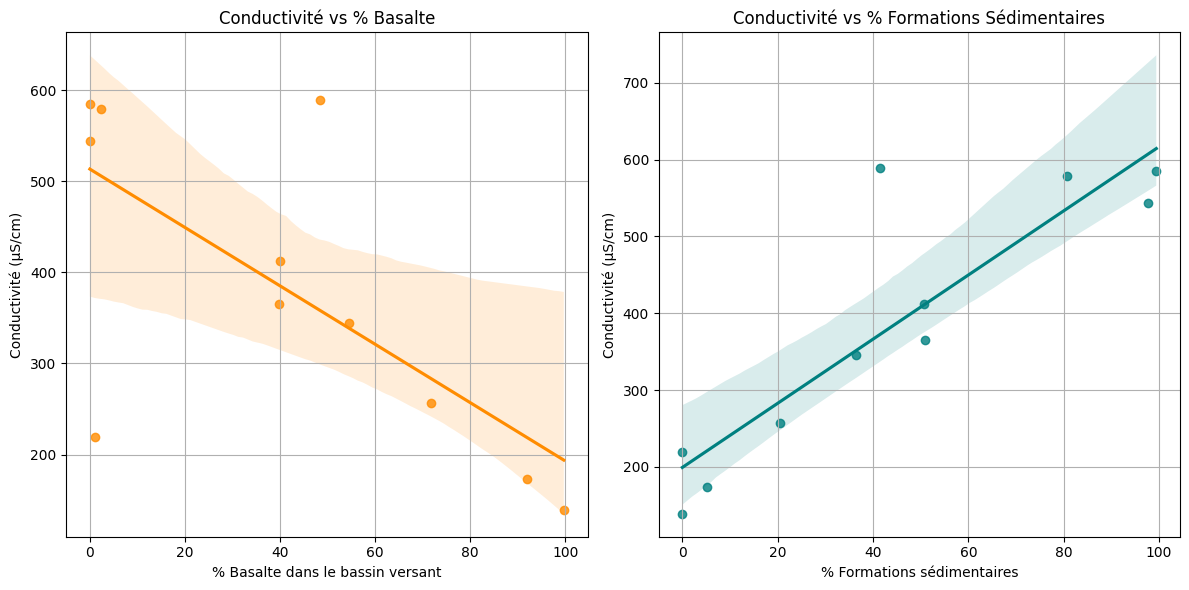

In [32]:
plt.figure(figsize=(12, 6))

# Correlation entre Conductivité vs % Basalt dans l'aire drainee en amont des points d'echantillonages
plt.subplot(1, 2, 1)
sns.regplot(data=dataframe, x="pourcentage de basalt dans le BV", y="conductivite", color="darkorange")
plt.title("Conductivité vs % Basalte")
plt.xlabel("% Basalte dans le bassin versant")
plt.ylabel("Conductivité (µS/cm)")
plt.grid(True)

# Correlation entre Conductivité vs % Sédimentaire dans l'aire drainee en amont des points d'echantillonages
plt.subplot(1, 2, 2)
sns.regplot(data=dataframe, x="pourcentage de formations sedimentaire dans le BV", y="conductivite", color="teal")
plt.title("Conductivité vs % Formations Sédimentaires")
plt.xlabel("% Formations sédimentaires")
plt.ylabel("Conductivité (µS/cm)")
plt.grid(True)

plt.tight_layout()
plt.show()


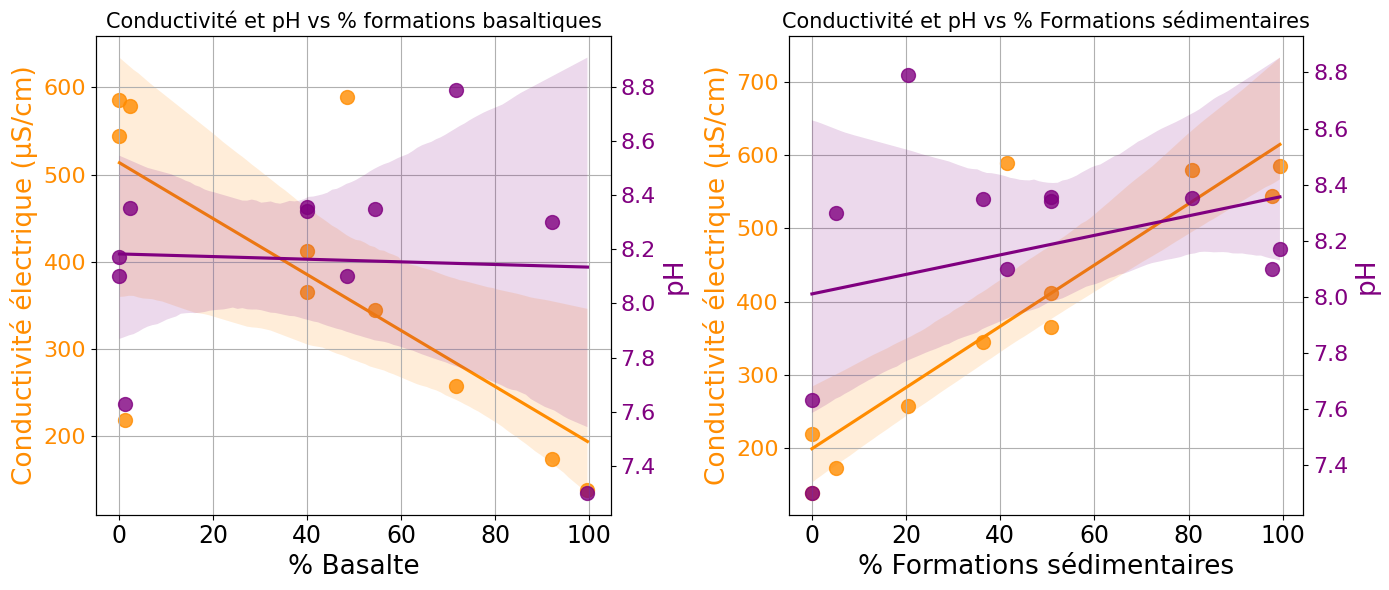

In [33]:
plt.figure(figsize=(14, 6))

# Sous-graphique 1: % Basalte
ax1 = plt.subplot(1, 2, 1)
color1 = "darkorange"
color2 = "purple"

# Conductivité
sns.regplot(data=dataframe, x="pourcentage de basalt dans le BV", y="conductivite", color=color1, ax=ax1, scatter_kws={"s": 100})
ax1.set_xlabel("% Basalte", fontsize=19)
ax1.set_ylabel("Conductivité électrique (µS/cm)", color=color1, fontsize=19)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=16)
ax1.tick_params(axis='x', labelsize=17)
ax1.set_title("Conductivité et pH vs % formations basaltiques", fontsize=15)
ax1.grid(True)

# pH avec axe secondaire
ax1b = ax1.twinx()
sns.regplot(data=dataframe, x="pourcentage de basalt dans le BV", y="pH", color=color2, ax=ax1b, scatter_kws={"s": 100})
ax1b.set_ylabel("pH", color=color2, fontsize=19)
ax1b.tick_params(axis='y', labelcolor=color2, labelsize=16)

# Sous-graphique 2: % Sédimentaire
ax2 = plt.subplot(1, 2, 2)
sns.regplot(data=dataframe, x="pourcentage de formations sedimentaire dans le BV", y="conductivite", color=color1, ax=ax2, scatter_kws={"s": 100})
ax2.set_xlabel("% Formations sédimentaires", fontsize=19)
ax2.set_ylabel("Conductivité électrique (µS/cm)", color=color1, fontsize=19)
ax2.tick_params(axis='y', labelcolor=color1, labelsize=16)
ax2.tick_params(axis='x', labelsize=17)
ax2.set_title("Conductivité et pH vs % Formations sédimentaires", fontsize=15)
ax2.grid(True)

# pH avec axe secondaire
ax2b = ax2.twinx()
sns.regplot(data=dataframe, x="pourcentage de formations sedimentaire dans le BV", y="pH", color=color2, ax=ax2b, scatter_kws={"s": 100})
ax2b.set_ylabel("pH", color=color2, fontsize=19)
ax2b.tick_params(axis='y', labelcolor=color2, labelsize=16 )

plt.tight_layout()
plt.show()
